In [366]:
# Author: Niko Bleidistel
# last change: 2026-08-19

# Package Import

In [367]:
from pathlib import Path
import sys
from os import makedirs

import re

import pandas as pd
import matplotlib.pyplot as plt

import importlib

In [368]:
PYTHON_HELPER_FOLDER = Path(r"py-helpers")

# Add the path to the custom packages to sys.path so that they can be imported
sys.path.append(str(PYTHON_HELPER_FOLDER.resolve()))

# import custom packages
import time_logging as tl
import comsol_data_import as cdi
import advanced_plotting_functions as apf

import comsol_data_plotting2 as cdp

# reload custom packages (for each execution) to reflect recent changes
_ = importlib.reload(tl)
_ = importlib.reload(cdi)
_ = importlib.reload(apf)
_ = importlib.reload(cdp)

# PATHS

In [369]:
MAIN_FOLDER = Path(r"R:\Bleidistel_Niko\mid res")
INPUT_FOLDER = MAIN_FOLDER / "RESULTS"
OUTPUT_FOLDER = MAIN_FOLDER / "SPECIFIC PLOTS"

makedirs(OUTPUT_FOLDER, exist_ok=True)  # create output folder if it doesn't exist

In [370]:
if False:
    input_folder = INPUT_FOLDER

    def mask(filename):
        return not (str(filename).endswith('.mph') or str(filename).endswith('.csv'))

    import seedir as sd
    sd.seedir(input_folder, style='lines', mask=mask)

# INITIALIZE

In [371]:
# initialize time logging
_ = tl.initialize_time_log(OUTPUT_FOLDER / 'time_log.csv')

## data folders

In [372]:
folders = [f for f in INPUT_FOLDER.rglob("*") if f.is_dir()]
data_export_folders = [f for f in folders if "Data Export" in f.name]
sweep_export_folders = [f for f in folders if "Sweep Export" in f.name]

if True:
    display(data_export_folders)
    display(sweep_export_folders)

[WindowsPath('R:/Bleidistel_Niko/mid res/RESULTS/02_00-H Designs/02_00_a-H design with minimized insulator/Data Export'),
 WindowsPath('R:/Bleidistel_Niko/mid res/RESULTS/02_00-H Designs/02_00_b-H design with full insulator/Data Export'),
 WindowsPath('R:/Bleidistel_Niko/mid res/RESULTS/01_xx-Coils and Grid Designs/01_01_a-Round spiral/Data Export'),
 WindowsPath('R:/Bleidistel_Niko/mid res/RESULTS/01_xx-Coils and Grid Designs/01_01_b-Rectangular spiral/Data Export'),
 WindowsPath('R:/Bleidistel_Niko/mid res/RESULTS/01_xx-Coils and Grid Designs/01_02_a-Grid/Data Export'),
 WindowsPath('R:/Bleidistel_Niko/mid res/RESULTS/01_xx-Coils and Grid Designs/01_03_a-Round spiral combined with grid/Data Export'),
 WindowsPath('R:/Bleidistel_Niko/mid res/RESULTS/01_xx-Coils and Grid Designs/01_03_b-Rectangular spiral combined with grid/Data Export'),
 WindowsPath('R:/Bleidistel_Niko/mid res/RESULTS/01_00-Meshing and POC/01_00_a-auto mesh/Data Export'),
 WindowsPath('R:/Bleidistel_Niko/mid res/RESU

[WindowsPath('R:/Bleidistel_Niko/mid res/RESULTS/02_00-H Designs/02_00_b-H design with full insulator/Sweep/Sweep Export'),
 WindowsPath('R:/Bleidistel_Niko/mid res/RESULTS/02_00-H Designs/02_00_a-H design with minimized insulator/Sweep/Sweep Export'),
 WindowsPath('R:/Bleidistel_Niko/mid res/RESULTS/01_xx-Coils and Grid Designs/01_03_b-Rectangular spiral combined with grid/Sweep - Voltage angles/Sweep Export'),
 WindowsPath('R:/Bleidistel_Niko/mid res/RESULTS/01_xx-Coils and Grid Designs/01_03_a-Round spiral combined with grid/Sweep - Voltage angles/Sweep Export'),
 WindowsPath('R:/Bleidistel_Niko/mid res/RESULTS/01_xx-Coils and Grid Designs/01_02_a-Grid/Sweep - Voltage angles and left_out_lines/left_out_lines - 0/Sweep Export'),
 WindowsPath('R:/Bleidistel_Niko/mid res/RESULTS/01_xx-Coils and Grid Designs/01_02_a-Grid/Sweep - Voltage angles and left_out_lines/left_out_lines - 1/Sweep Export'),
 WindowsPath('R:/Bleidistel_Niko/mid res/RESULTS/01_xx-Coils and Grid Designs/01_02_a-Grid/

In [373]:
MODELS = [
    "02_00_a-H design with minimized insulator",
    "02_00_b-H design with full insulator",
    "01_01_a-Round spiral",
    "01_01_b-Rectangular spiral",
]

# TRANSLATION (Constants)

In [374]:
TRANSLATE_PLOTLABELS = {
    "x":                r"$x$-axis [m]",
    "y":                r"$y$-axis [m]",
    "z":                r"$z$-axis [m]",
    "mf.normB (T)":     r"Magnetic flux density, norm $|\vec{B}|$ [T]",
    "mf.Bx (T)":        r"Magnetic flux density, x-component $B_x$ [T]", 
    "mf.By (T)":        r"Magnetic flux density, y-component $B_y$ [T]", 
    "mf.Bz (T)":        r"Magnetic flux density, z-component $B_z$ [T]",
    "T (K)":            r"Temperature $T$ [K]",
    "V (V)":            r"Electric potential $V$ [V]",
    "ec.normJ (A/m^2)": r"Current density, norm $|\vec{J}|$ [A/m^2]",
    "ec.Jx (A/m^2)":    r"Current density, x-component $J_x$ [A/m^2]",
    "ec.Jy (A/m^2)":    r"Current density, y-component $J_y$ [A/m^2]",
    "ec.Jz (A/m^2)":    r"Current density, z-component $J_z$ [A/m^2]",
    "Set angle (°)":    r"Set angle $\theta$ [°]",
    "Angle Error (°)":  r"Angle error $\Delta\theta$ [°]",
}

In [375]:
X_AXIS_PARAMS = ["x", "y", "z"]
Y_AXIS_PARAMS = [key for key in TRANSLATE_PLOTLABELS.keys() if key not in X_AXIS_PARAMS]

# STANDARD PLOTS

In [376]:
MODEL_2_PLOT = [
    "01_03_b-Rectangular spiral combined with grid",
]

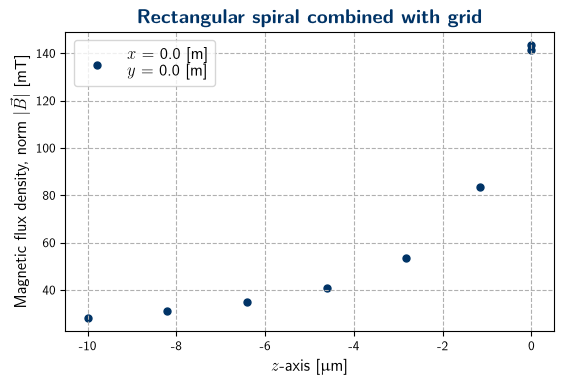

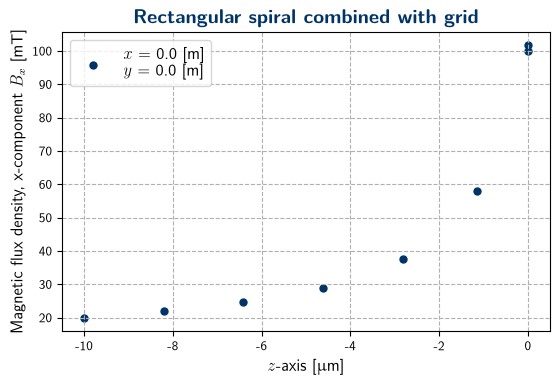

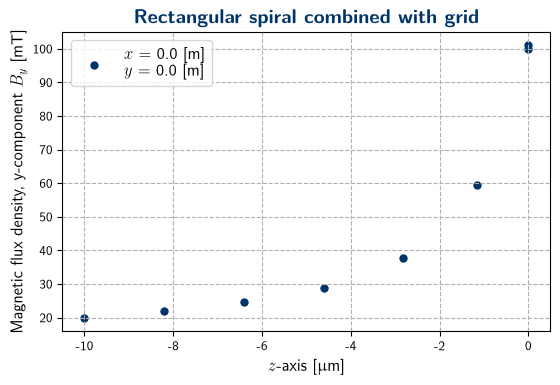

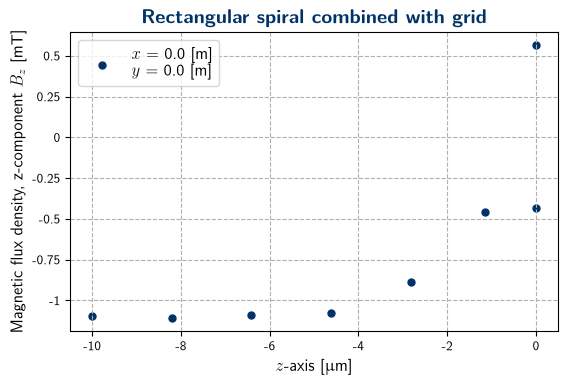

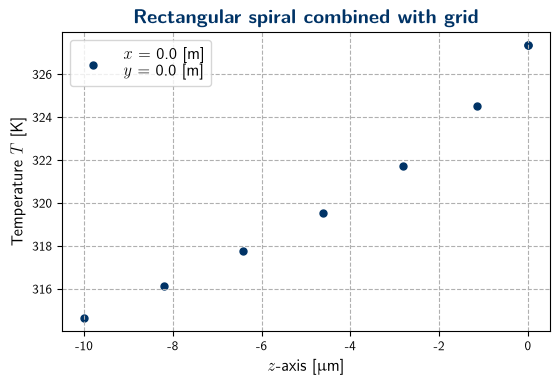

In [377]:
if True:
    output_folder = OUTPUT_FOLDER

    for data_export_folder in data_export_folders:

        model_folder = data_export_folder.parent
        if model_folder.stem not in MODEL_2_PLOT:
            continue  # skip this model if it's not in the list of models to plot

        tl.log_message(f"Starting creating standard plots for model: {data_export_folder.parent.stem}")

        # define output folder for plots
        plot_folder = output_folder / data_export_folder.parent.stem

        # get a list of all csv files in the "Data Export" subfolder
        tl.log_message(f"Importing data from CSV files in folder: {data_export_folder}")
        df_terminal = pd.DataFrame()
        df_parameters = pd.DataFrame()

        csv_files = list(data_export_folder.glob("*.csv"))
        for csv_file in csv_files:
            if re.match(r".*-terminals$", csv_file.stem):
                df_terminal = pd.read_csv(csv_file)
                tl.log_message(f"Imported terminal data")
            elif re.match(r".*-parameters$", csv_file.stem):
                df_parameters = pd.read_csv(csv_file)
                tl.log_message(f"Imported parameter data")


        # get a list of all txt files in the "Data Export" subfolder
        txt_files = list(data_export_folder.glob("*.txt"))
        for txt_file in txt_files:
            tl.log_message(f"Processing txt file: {txt_file.stem}")
            header_data, df = cdi.read_comsol_export(str(txt_file))
            modelstem = str(header_data.get('Model')).replace(".mph", "")

            title_match = re.match(r"(.*)-(.*)-.*", modelstem)
            modeltitle = title_match.group(2) if title_match else modelstem



            if re.match(r".*-depth_exported_data$", txt_file.stem):
                df.drop(labels=["x", "y"], axis=1, inplace=True)

                depth_folder = plot_folder / "z axis"
                makedirs(depth_folder, exist_ok=True)  # create output folder if it doesn't exist

                xparam = "z"
                for yparam in Y_AXIS_PARAMS:
                    if yparam in df.columns:
                        tl.log_message(f"Started plotting of {yparam} vs {xparam}")

                        fig, ax = cdp.standard_scatter_plot_df(
                            df = df,
                            x = xparam,
                            y = yparam,
                            label = "x = 0 \ny = 0",
                            translation_dict = TRANSLATE_PLOTLABELS,
                            fraction_textwidth = 1.0,
                            title = modeltitle.split("-")[-1],
                            x_label = xparam,
                            y_label = yparam,
                        )
                        plt.show()
                        tl.log_message(f"Finished plotting of {yparam} vs {xparam}")

# ERROR PLOT

In [378]:
ERROR_SWEEP_MODELS = [
    "01_02_a-Grid",
]

In [379]:
ERROR_DEPTH = -3e-6 #m
ANGLES = list(range(0, 91, 3))  # angles from 0 to 90 degrees in steps of 3 degrees

# End

In [380]:
tl.log_message("Finished creating standard plots for all models.")